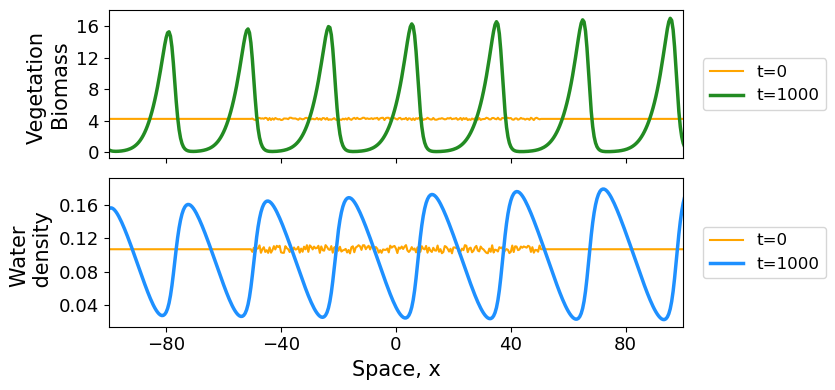

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

#Model parameters
A= 2
B = 0.45
V = 182.5         
d = 500.0

dx = 0.5

L_big = 800.0          #big periodic domain
L_in  = 100.0          #inner “analysis” subdomain

N = int(L_big/dx)
x = np.linspace(0.0, L_big, N, endpoint=False)

x0 = L_big/2
inner_mask = np.abs(x - x0) <= L_in/2

#Steady state (vegetated)
disc = A*A - 4*B*B
if disc <= 0:
    raise ValueError("Need A^2 > 4 B^2 for the vegetated steady state.")

u_ss = 2*B / (A - np.sqrt(disc))
w_ss = (A - np.sqrt(disc)) / 2

#Initial condition:
#steady state everywhere, random perturbation only inside inner window
rng = np.random.default_rng(0)
eps_u, eps_w = 0.3, 1e-2

u = np.full(N, u_ss)
w = np.full(N, w_ss)

u[inner_mask] += eps_u * (rng.random(inner_mask.sum()) - 0.5)
w[inner_mask] += eps_w * (rng.random(inner_mask.sum()) - 0.5)

u[u < 0] = 0.0
w[w < 0] = 0.0

u0 = u.copy()
w0 = w.copy()

#Time integration (IMEX + FFT)
#linear terms (diffusion+advection) implicit, reactions explicit
T  = 1000.0
dt = 0.01
nsteps = int(round(T/dt))

k = 2*np.pi*np.fft.fftfreq(N, d=dx)

den_u = 1.0 + dt*(k**2)
den_w = 1.0 + dt*d*(k**2) - 1j*dt*V*k

for _ in range(nsteps):
    Ru = w*u*u - B*u
    Rw = A - w - w*u*u

    u_hat = np.fft.fft(u)
    w_hat = np.fft.fft(w)

    u = np.fft.ifft((u_hat + dt*np.fft.fft(Ru)) / den_u).real
    w = np.fft.ifft((w_hat + dt*np.fft.fft(Rw)) / den_w).real

    u[u < 0] = 0.0
    w[w < 0] = 0.0


#Plot on [-100, 100]
x_rel = x - x0

fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)

ax[0].plot(x_rel, u0, lw=1.5, color="orange", label="t=0")
ax[0].plot(x_rel, u,  lw=2.5, color="forestgreen", label="t=1000")
ax[0].set_ylabel("Vegetation \nBiomass", fontsize=15)
ax[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=12)

ax[1].plot(x_rel, w0, lw=1.5, color="orange", label="t=0")
ax[1].plot(x_rel, w,  lw=2.5, color="dodgerblue", label="t=1000")
ax[1].set_xlabel("Space, x", fontsize=15)
ax[1].set_ylabel("Water \n density", fontsize=15)
ax[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=12)

ax[0].set_xlim(-100, 100)
ax[1].set_xlim(-100, 100)

for axt in ax:
    axt.xaxis.set_major_locator(MaxNLocator(nbins=5))
    axt.yaxis.set_major_locator(MaxNLocator(nbins=5))
    axt.tick_params(axis='both', which='major', labelsize=13)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig("Patterned Solution.pdf", format="pdf", bbox_inches="tight")
plt.show()

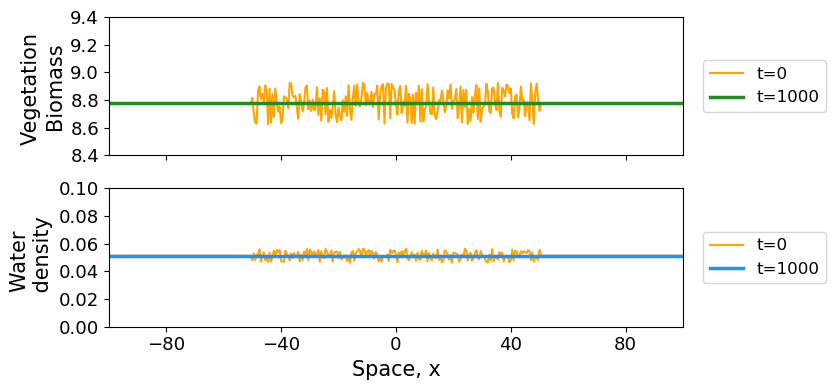

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

#Model parameters
A= 4
B = 0.45
V = 182.5         
D_u = 1.0
D_w = 500.0

dx = 0.5

L_big = 800.0          #big periodic domain
L_in  = 100.0          #inner “analysis” subdomain

N = int(L_big/dx)
x = np.linspace(0.0, L_big, N, endpoint=False)

x0 = L_big/2
inner_mask = np.abs(x - x0) <= L_in/2

#Steady state (vegetated)
disc = A*A - 4*B*B
if disc <= 0:
    raise ValueError("Need A^2 > 4 B^2 for the vegetated steady state.")

u_ss = 2*B / (A - np.sqrt(disc))
w_ss = (A - np.sqrt(disc)) / 2

#Initial condition:
#steady state everywhere, random perturbation only inside inner window
rng = np.random.default_rng(0)
eps_u, eps_w = 0.3, 1e-2

u = np.full(N, u_ss)
w = np.full(N, w_ss)

u[inner_mask] += eps_u * (rng.random(inner_mask.sum()) - 0.5)
w[inner_mask] += eps_w * (rng.random(inner_mask.sum()) - 0.5)

u[u < 0] = 0.0
w[w < 0] = 0.0

u0 = u.copy()
w0 = w.copy()

#Time integration (IMEX + FFT)
#linear terms (diffusion+advection) implicit, reactions explicit
T  = 1000.0
dt = 0.01
nsteps = int(round(T/dt))

k = 2*np.pi*np.fft.fftfreq(N, d=dx)

den_u = 1.0 + dt*D_u*(k**2)
den_w = 1.0 + dt*D_w*(k**2) - 1j*dt*V*k

for _ in range(nsteps):
    Ru = w*u*u - B*u
    Rw = A - w - w*u*u

    u_hat = np.fft.fft(u)
    w_hat = np.fft.fft(w)

    u = np.fft.ifft((u_hat + dt*np.fft.fft(Ru)) / den_u).real
    w = np.fft.ifft((w_hat + dt*np.fft.fft(Rw)) / den_w).real

    u[u < 0] = 0.0
    w[w < 0] = 0.0


#Plot on [-100, 100]
x_rel = x - x0

fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)

ax[0].plot(x_rel, u0, lw=1.5, color="orange", label="t=0")
ax[0].plot(x_rel, u,  lw=2.5, color="forestgreen", label="t=1000")
ax[0].set_ylabel("Vegetation \nBiomass", fontsize=15)
ax[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=12)

ax[1].plot(x_rel, w0, lw=1.5, color="orange", label="t=0")
ax[1].plot(x_rel, w,  lw=2.5, color="dodgerblue", label="t=1000")
ax[1].set_xlabel("Space, x", fontsize=15)
ax[1].set_ylabel("Water \n density", fontsize=15)
ax[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=12)

ax[0].set_xlim(-100, 100)
ax[0].set_ylim(8.4, 9.4)
ax[1].set_xlim(-100, 100)
ax[1].set_ylim(0, 0.1)
for axt in ax:
    axt.xaxis.set_major_locator(MaxNLocator(nbins=5))
    axt.yaxis.set_major_locator(MaxNLocator(nbins=5))
    axt.tick_params(axis='both', which='major', labelsize=13)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig("No patterned Solution.pdf", format="pdf", bbox_inches="tight")
plt.show()

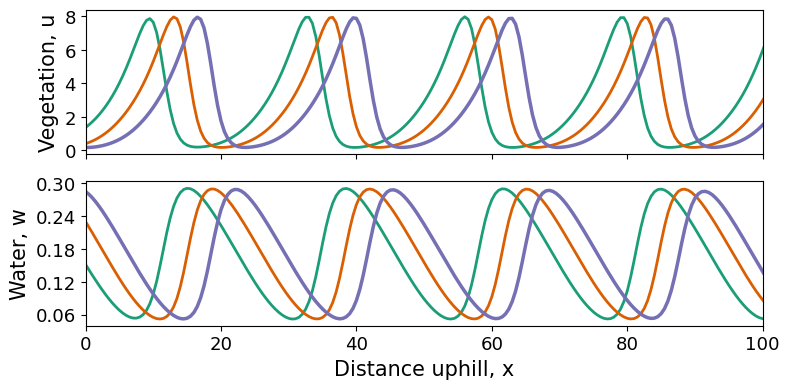

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

#Model parameters
A = 1.4
B = 0.45
V = 50.0
d = 100.0

dx = 0.5

L_big = 800.0          #big periodic domain
L_in  = 100.0          #inner analysis subdomain

N = int(L_big / dx)
x = np.linspace(0.0, L_big, N, endpoint=False)

x0 = L_big / 2
inner_mask = np.abs(x - x0) <= L_in / 2

#Steady state (vegetated)
disc = A * A - 4 * B * B
if disc <= 0:
    raise ValueError("Need A^2 > 4 B^2 for the vegetated steady state.")

u_ss = 2 * B / (A - np.sqrt(disc))
w_ss = (A - np.sqrt(disc)) / 2

#Initial condition:
#steady state everywhere, random perturbation only inside inner window
rng = np.random.default_rng(0)
eps_u, eps_w = 1e-2, 1e-2

u = np.full(N, u_ss)
w = np.full(N, w_ss)

u[inner_mask] += eps_u * (rng.random(inner_mask.sum()) - 0.5)
w[inner_mask] += eps_w * (rng.random(inner_mask.sum()) - 0.5)

u[u < 0] = 0.0
w[w < 0] = 0.0

u0 = u.copy()
w0 = w.copy()

#Time integration (IMEX + FFT)
#linear terms (diffusion + advection) implicit, reactions explicit
T = 800.0
dt = 0.01
nsteps = int(round(T / dt))

k = 2 * np.pi * np.fft.fftfreq(N, d=dx)

den_u = 1.0 + dt * (k**2)
den_w = 1.0 + dt * d * (k**2) - 1j * dt * V * k

#Times to save
save_times = [200.0, 400.0, 600.0]
save_steps = {int(round(t / dt)): t for t in save_times}
snapshots = {}

for step in range(1, nsteps + 1):
    Ru = w * u * u - B * u
    Rw = A - w - w * u * u

    u_hat = np.fft.fft(u)
    w_hat = np.fft.fft(w)

    u = np.fft.ifft((u_hat + dt * np.fft.fft(Ru)) / den_u).real
    w = np.fft.ifft((w_hat + dt * np.fft.fft(Rw)) / den_w).real

    u[u < 0] = 0.0
    w[w < 0] = 0.0

    if step in save_steps:
        snapshots[save_steps[step]] = (u.copy(), w.copy())

#Plot on [-100, 100]
x_rel = x    #centre at 0

fig, ax = plt.subplots(2, 1, figsize=(8, 4), sharex=True)

#u plots
ax[0].plot(x_rel, snapshots[200.0][0], lw=2.0, color= "#1b9e77")
ax[0].plot(x_rel, snapshots[400.0][0], lw=2.0, color = "#d95f02")
ax[0].plot(x_rel, snapshots[600.0][0], lw=2.5, color = "#7570b3")
ax[0].set_ylabel("Vegetation, u", fontsize=15)

#w plots
ax[1].plot(x_rel, snapshots[200.0][1], lw=2.0, color = "#1b9e77")
ax[1].plot(x_rel, snapshots[400.0][1], lw=2.0, color = "#d95f02")
ax[1].plot(x_rel, snapshots[600.0][1], lw=2.5, color = "#7570b3")
ax[1].set_xlabel("Distance uphill, x", fontsize=15)
ax[1].set_ylabel("Water, w", fontsize=15)

ax[0].set_xlim(0, 100)
ax[1].set_xlim(0, 100)

for axt in ax:
    axt.xaxis.set_major_locator(MaxNLocator(nbins=5))
    axt.yaxis.set_major_locator(MaxNLocator(nbins=5))
    axt.tick_params(axis='both', which='major', labelsize=13)

plt.tight_layout()
plt.savefig("Patterned Solution waves.pdf", format="pdf")
plt.show()